<a href="https://colab.research.google.com/github/ShezzTRANS/AI-Tools/blob/main/Titanicdataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TITANIC EXPLORATORY DATA ANALYSIS (EDA)
Step-by-Step Comprehensive Analysis

Following the structured approach:
1. Data Loading and Pre-processing
2. Basic Analysis
3. Intermediate Analysis
4. Advanced Analysis
5. Conclusion and Interpretation



1. DATA LOADING AND PRE-PROCESSING
Handling missing data correctly is critical because poor preprocessing
can lead to biased insights and incorrect conclusions later in the analysis.


In [57]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
import warnings
import io
import zipfile # Import zipfile

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

uploaded = files.upload()
print(uploaded)

# Load uploaded file from the zip archive
# Assuming 'train.csv' is the main file for analysis
zip_file_name = list(uploaded.keys())[0]
with zipfile.ZipFile(io.BytesIO(uploaded[zip_file_name]), 'r') as zf:
    with zf.open('train.csv') as csv_file:
        df = pd.read_csv(csv_file)

df.head()


Saving titanic.zip to titanic (10).zip
{'titanic (10).zip': b'PK\x03\x04-\x00\x00\x00\x08\x00&\x12\x8bOA\xaa\xebr\xff\xff\xff\xff\xff\xff\xff\xff\x15\x00\x14\x00gender_submission.csv\x01\x00\x10\x00\xba\x0c\x00\x00\x00\x00\x00\x00h\x03\x00\x00\x00\x00\x00\x00-\x961\x8e\x1d7\x10Ds\x03\xbe\xc9\x06S\xd5$\xbby\x04g\x02t\x02\x01Z\x08J\x1cH\xb0\xce\xef\xbf[/*p\xf6\xe3\xa1\x9a3O\xad/\xdf~\xff~\xff\xf7\xc7\xfb\xaf\x7f\xbe\xbf}\xfd\xef\xd7\x9f\x9f\x7f\xde\xbf\xff\xfd\xd7\\\xbf=\x1fQo\xfa\x88\x95\xd3N\x9c<\xec\x9c&\xa7\xfbq\xba\xcf\xf3q\xba\x8frr\xa2\x12+\x7f\xdb9\x9d\x9c:1y\x18\x8aB\x91\x12\xa1(\x14\x85\xa2P\x14\x8a:\xa7\xc9)\x14?\x89tq(\x0e\xc5\xa1x\'N\x1e\x86\xe2P|?\xa3B\xa9P*\x94\n\xa5V"\x94J\x97\n\xa52Q\xa5\xcb\xcaD+\x13\xadPV(+]V(+]V(+\x94\x15\xcaN\x97\x1d\xca\x0ee\x87\xb2\xd3e\x87\xb2C\xd9\xb9\xdd\x9d\x89v(\'\x94\x13\xcaq"\x94\x93.\'\xb7{2\xd1I\x97\x93.\'\xf7\xd2\xa1t(\x9d.\x1dJ\xa7K\x87\xd2\xe9\xd2\xa1t\xbat(\x93{\x99\xdc\xee\xa4\xcb\x842\xe92\xa1L(\x13\xca\x842\x99\xe8\x86rC\xb9\xa1\xdc

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [61]:
# Handle missing values
df["Age"] = df.groupby(["Pclass", "Sex"])["Age"].transform(
    lambda x: x.fillna(x.median())
)

df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

# Cabin feature
if "Cabin" in df.columns:
    df["Has_Cabin"] = df["Cabin"].notna().astype(int)
    df.drop(columns=["Cabin"], inplace=True)
else:
    # If Cabin column is already dropped or was never present,
    # set Has_Cabin to 0 (assuming no cabin information)
    df["Has_Cabin"] = 0

# Feature engineering
df["Family_Size"] = df["SibSp"] + df["Parch"] + 1
df["Is_Alone"] = (df["Family_Size"] == 1).astype(int)

# Extract titles
df["Title"] = df["Name"].str.extract(" ([A-Za-z]+)\\. ", expand=False)

title_mapping = {
    "Mr": "Mr", "Miss": "Miss", "Mrs": "Mrs", "Master": "Master",
    "Dr": "Rare", "Rev": "Rare", "Col": "Rare", "Major": "Rare",
    "Mlle": "Miss", "Mme": "Mrs", "Don": "Rare", "Dona": "Rare",
    "Lady": "Rare", "Countess": "Rare", "Jonkheer": "Rare",
    "Sir": "Rare", "Capt": "Rare", "Ms": "Miss"
}
df["Title"] = df["Title"].map(title_mapping)

# Age & Fare groups
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[0, 12, 18, 35, 60, 100],
    labels=["Child", "Teen", "Adult", "Middle-Aged", "Senior"]
)

df["Fare_Group"] = pd.qcut(df["Fare"], 4, labels=["Low", "Medium", "High", "Very High"])

df.isnull().sum()


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


## Step 2: Basic Analysis

This step explores the dataset using descriptive statistics
and simple visualizations.

The goal is to understand:
- Passenger demographics
- Overall survival rate
- Distributions of age, fare, gender, and passenger class



step 2 : Intermediate Analysis
Here we investigate relationships between multiple variables
and survival outcomes.

We analyze:
- Survival rates across age groups
- Family size effects
- Interaction between class and gender

This stage helps reveal hidden patterns not visible
through simple statistics alone.

Total Passengers: 891
Survival Rate: 0.3838383838383838


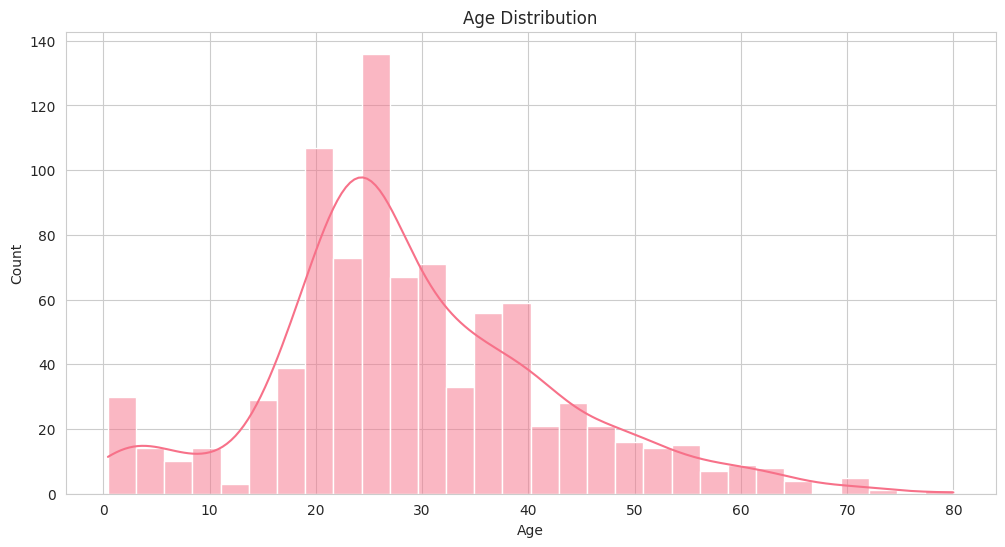

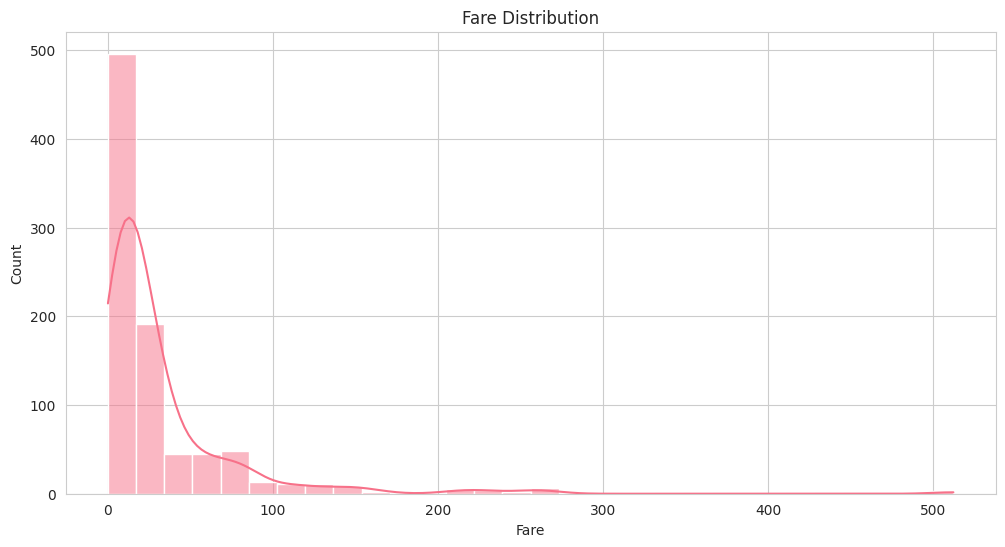

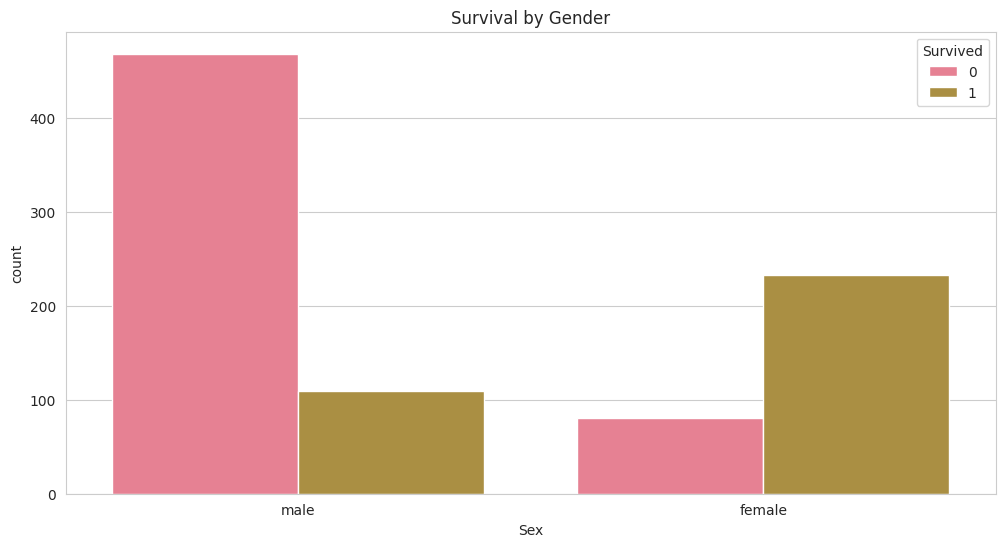

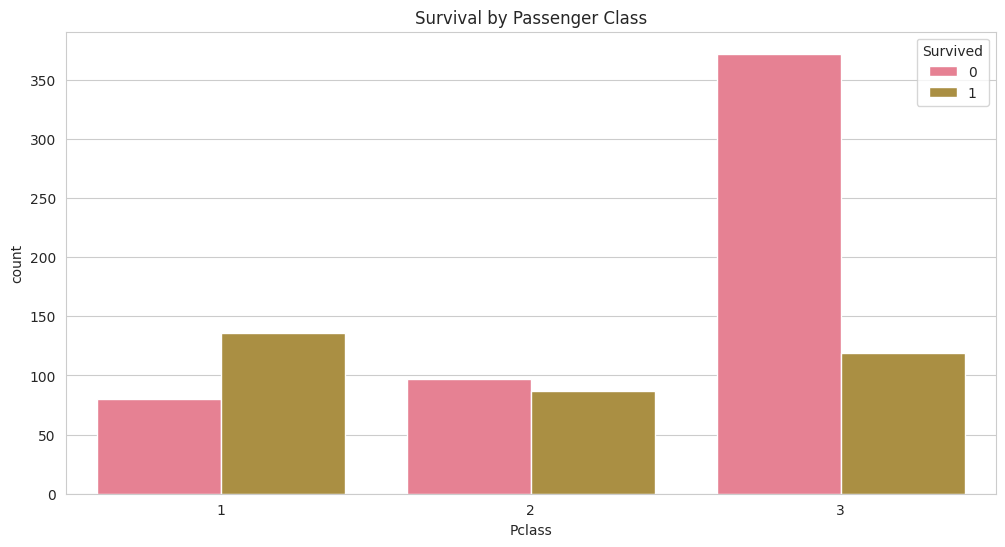

In [62]:
# Descriptive statistics
df.describe()

df.describe(include="object")

# Survival statistics
total_passengers = len(df)
survival_rate = df["Survived"].mean()

print("Total Passengers:", total_passengers)
print("Survival Rate:", survival_rate)

# Basic visualizations
sns.histplot(df["Age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

sns.histplot(df["Fare"], bins=30, kde=True)
plt.title("Fare Distribution")
plt.show()

sns.countplot(data=df, x="Sex", hue="Survived")
plt.title("Survival by Gender")
plt.show()

sns.countplot(data=df, x="Pclass", hue="Survived")
plt.title("Survival by Passenger Class")
plt.show()


step 3: Intermediate Analysis

Here we investigate relationships between multiple variables
and survival outcomes.

We analyze:
- Survival rates across age groups
- Family size effects
- Interaction between class and gender

This stage helps reveal hidden patterns not visible
through simple statistics alone.


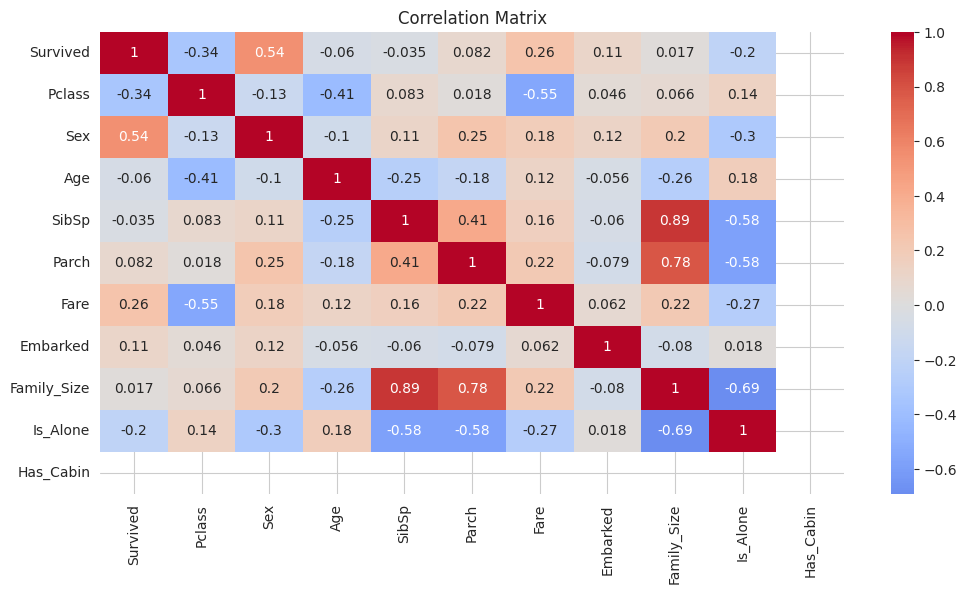

In [63]:
# Encode categorical variables
df_encoded = df.copy()
df_encoded["Sex"] = df_encoded["Sex"].map({"male": 0, "female": 1})
df_encoded["Embarked"] = df_encoded["Embarked"].map({"S": 0, "C": 1, "Q": 2})
df_encoded["Title"] = df_encoded["Title"].map(
    {"Mr": 0, "Miss": 1, "Mrs": 2, "Master": 3, "Rare": 4}
)

features = [
    "Survived", "Pclass", "Sex", "Age", "SibSp", "Parch",
    "Fare", "Embarked", "Family_Size", "Is_Alone", "Has_Cabin"
]

correlation_matrix = df_encoded[features].corr()

sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()


STEP 4: ADVANCED ANALYSIS
 Intermediate Analysis

Here we investigate relationships between multiple variables
and survival outcomes.

We analyze:
- Survival rates across age groups
- Family size effects
- Interaction between class and gender

This stage helps reveal hidden patterns not visible
through simple statistics alone.


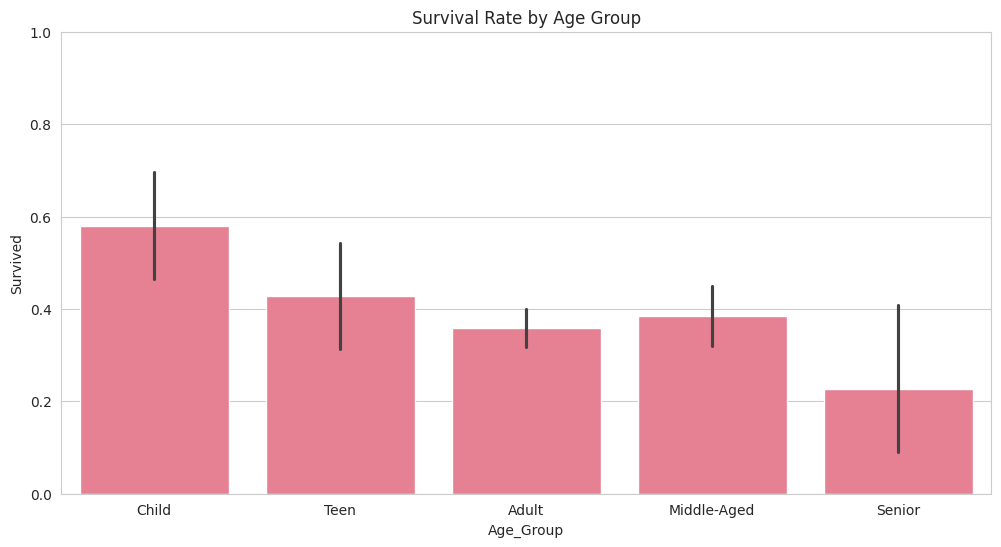

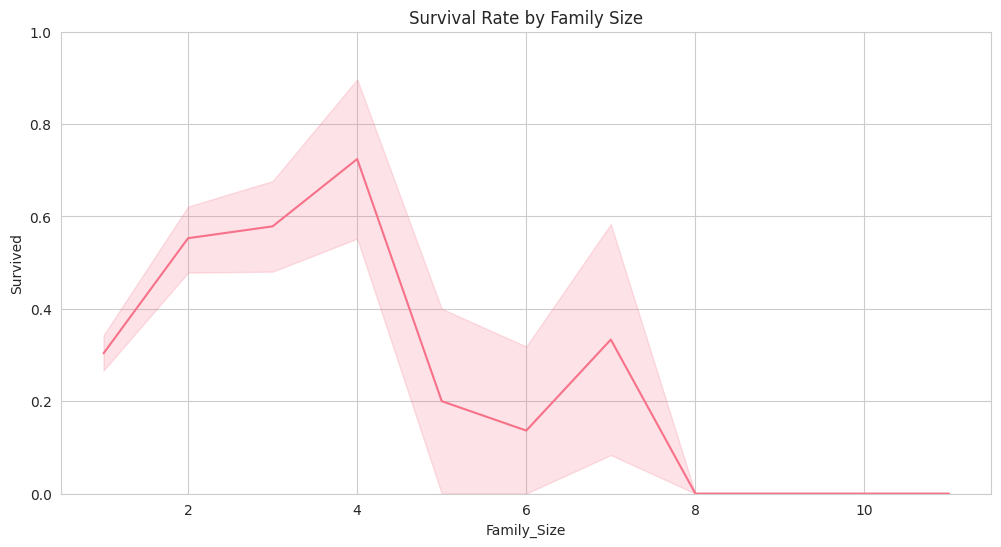

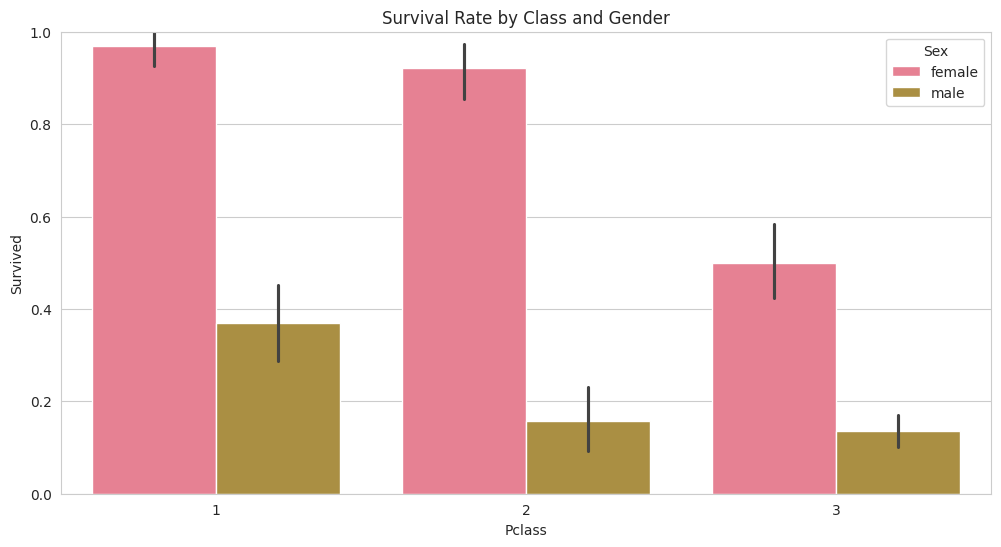

In [64]:
sns.barplot(data=df, x="Age_Group", y="Survived")
plt.title("Survival Rate by Age Group")
plt.ylim(0, 1)
plt.show()

sns.lineplot(data=df, x="Family_Size", y="Survived")
plt.title("Survival Rate by Family Size")
plt.ylim(0, 1)
plt.show()

sns.barplot(data=df, x="Pclass", y="Survived", hue="Sex")
plt.title("Survival Rate by Class and Gender")
plt.ylim(0, 1)
plt.show()


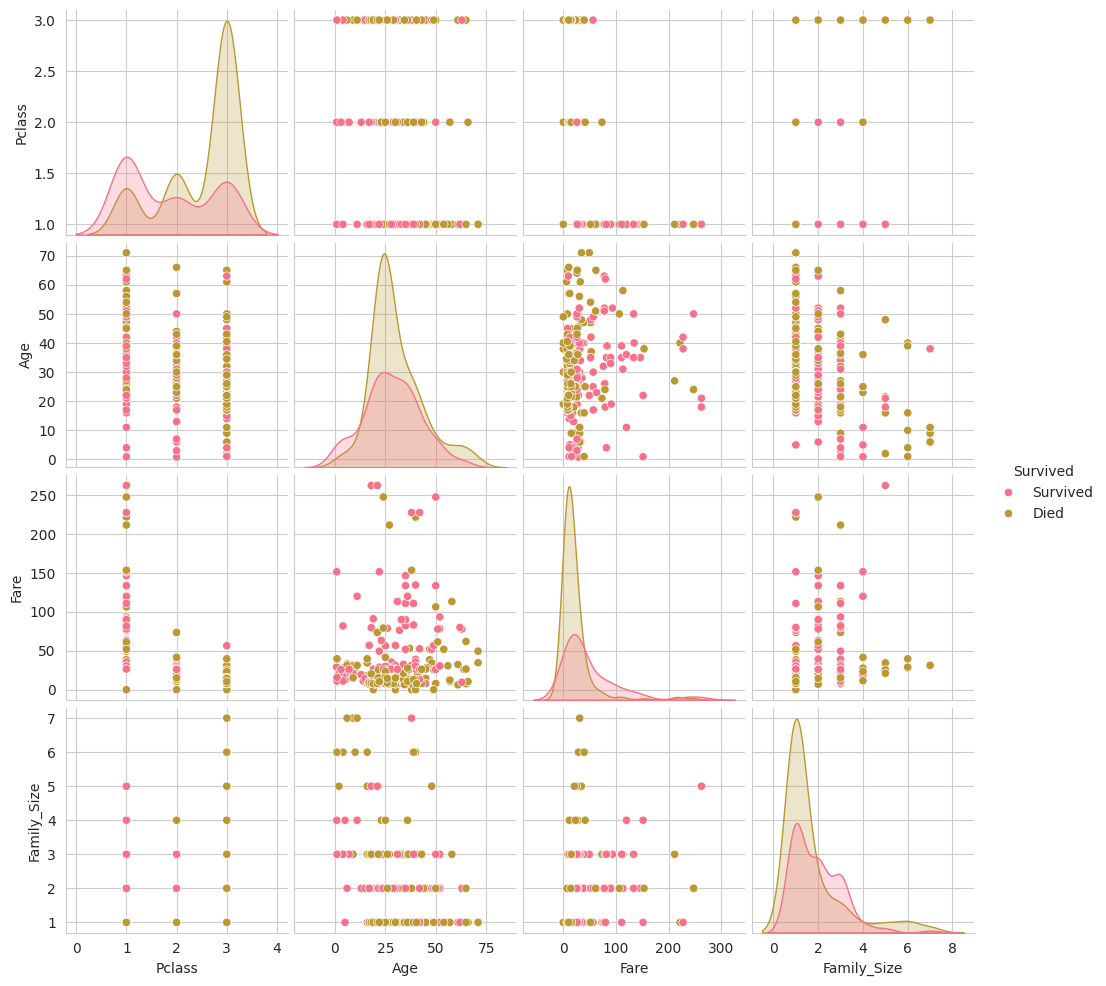

Gender p-value: 1.1973570627755645e-58
Class p-value: 4.549251711298793e-23


In [65]:
# Pairplot (SAFE SAMPLE)
pairplot_data = df[["Survived", "Pclass", "Age", "Fare", "Family_Size"]].copy()
pairplot_data["Survived"] = pairplot_data["Survived"].map({0: "Died", 1: "Survived"})

sns.pairplot(
    pairplot_data.sample(300, random_state=42),
    hue="Survived",
    diag_kind="kde"
)
plt.show()

# Statistical tests
chi2, p_gender, _, _ = chi2_contingency(pd.crosstab(df["Survived"], df["Sex"]))
chi2, p_class, _, _ = chi2_contingency(pd.crosstab(df["Survived"], df["Pclass"]))

print("Gender p-value:", p_gender)
print("Class p-value:", p_class)


Step 5: Conclusion and Interpretation

The analysis shows that survival on the Titanic
was strongly influenced by social and demographic factors.

Key conclusions:
- Gender was the strongest predictor of survival
- Higher passenger class increased survival chances
- Children and small families had better outcomes
- Higher fares correlated with higher survival rates

These findings reflect the social structure
and emergency response priorities of the time.


In [66]:
print("Overall Survival Rate:", df["Survived"].mean())
print("Survival Rate by Gender:")
print(df.groupby("Sex")["Survived"].mean())

print("\nSurvival Rate by Class:")
print(df.groupby("Pclass")["Survived"].mean())

print("\nSurvival Rate by Age Group:")
print(df.groupby("Age_Group")["Survived"].mean())

print("\nEDA PIPELINE COMPLETED SUCCESSFULLY")


Overall Survival Rate: 0.3838383838383838
Survival Rate by Gender:
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

Survival Rate by Class:
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

Survival Rate by Age Group:
Age_Group
Child          0.579710
Teen           0.428571
Adult          0.357977
Middle-Aged    0.384259
Senior         0.227273
Name: Survived, dtype: float64

EDA PIPELINE COMPLETED SUCCESSFULLY
